In [1]:


#1) Imports and paths

import os
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy import signal
from tqdm.auto import tqdm

import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = "data"   
TRAIN_CSV = os.path.join(ROOT, "train.csv")
TEST_CSV  = os.path.join(ROOT, "test.csv")
RAW_DIR   = os.path.join(ROOT, "data")

FEATURE_TRAIN_OUT = os.path.join(ROOT, "train_features_v2.csv")
FEATURE_TEST_OUT  = os.path.join(ROOT, "test_features_v2.csv")
SUBMISSION_OUT    = os.path.join(ROOT, "submit_motion_model.csv")

/home/celosia/Tom/VSCode/ML_Med/ParkinsonProject/ParkinsonVenv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Save PNG
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name, fig=None):
    if fig is None:
        fig = plt.gcf()
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure:", path)

In [3]:


#Metadata cleaning
def clean_metadata(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    out = df.copy()

    # gender "0" -> Unknown
    out["gender"] = out["gender"].replace({0: "Unknown", "0": "Unknown"}).astype(str)

    # age 0 is almost certainly missing, not true age
    out["age_missing"] = (out["age"] == 0).astype(int)
    out["age"] = out["age"].replace({0: np.nan}).astype(float)

    out["patient_off_on"] = out["patient_off_on"].astype(str)
    out["doctor_diagnosis_0_5"] = out["doctor_diagnosis_0_5"].astype(float)

    if is_train:
        out["folder_path"] = out["folder_path"].astype(str)

    return out


train = clean_metadata(pd.read_csv(TRAIN_CSV), is_train=True)
test  = clean_metadata(pd.read_csv(TEST_CSV), is_train=False)

print(train.shape, test.shape)
display(train.head())

(833, 7) (357, 6)


,data_file_name,folder_path,gender,age,patient_off_on,doctor_diagnosis_0_5,age_missing
0,raw_data_d786d645-db38-11ec-b494-e82aea2c97f4.csv,Kinetic tremor,Male,52.0,off,1.0,0
1,raw_data_bdcba44f-0d6a-11ed-8857-b6da2cf29e9d.csv,Postural tremor,Male,78.0,on,0.0,0
2,raw_data_750c0f09-b09a-11ec-9699-58a023d3f6d9.csv,Postural tremor,Male,71.0,on,0.0,0
3,raw_data_d90846c3-3969-11ed-a96d-b469216ca443.csv,Fist,Male,23.0,off,1.0,0
4,raw_data_c27fbeb3-1882-11ed-95c1-b469216ca443.csv,Kinetic tremor,Male,23.0,off,2.0,0


In [4]:
LANDMARKS = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_FINGER_MCP", "INDEX_FINGER_PIP", "INDEX_FINGER_DIP", "INDEX_FINGER_TIP",
    "MIDDLE_FINGER_MCP", "MIDDLE_FINGER_PIP", "MIDDLE_FINGER_DIP", "MIDDLE_FINGER_TIP",
    "RING_FINGER_MCP", "RING_FINGER_PIP", "RING_FINGER_DIP", "RING_FINGER_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]

TIPS = [
    "THUMB_TIP",
    "INDEX_FINGER_TIP",
    "MIDDLE_FINGER_TIP",
    "RING_FINGER_TIP",
    "PINKY_TIP",
]

ADJ_TIP_PAIRS = [
    ("THUMB_TIP", "INDEX_FINGER_TIP"),
    ("INDEX_FINGER_TIP", "MIDDLE_FINGER_TIP"),
    ("MIDDLE_FINGER_TIP", "RING_FINGER_TIP"),
    ("RING_FINGER_TIP", "PINKY_TIP"),
]

In [5]:


#Timestamp cleaning and segmentation
'''
preprocessing.
- detect resets (dt <= 0)
- detect giant gaps
- split the recording into continuous segments
- rebuild a local clean time inside each segment
- extract features segment-wise
- aggregate them back into one feature row per file
'''



def split_into_segments(
    df: pd.DataFrame,
    time_col: str = "TIME",
    min_frames: int = 20,
    gap_abs_seconds: float = 0.50,
    gap_mult: float = 8.0,
):
    """
    Split a raw file into continuous segments using:
      - timestamp reversal / reset (dt <= 0)
      - giant time jump (dt > max(gap_abs_seconds, gap_mult * median_positive_dt))

    Returns:
      kept_segments: list[pd.DataFrame]
      qc: dict of quality-control stats
    """
    out_segments = []

    if time_col not in df.columns:
        seg = df.copy()
        seg["_segment_id"] = 0
        seg["_segment_local_time"] = np.arange(len(seg), dtype=float)
        qc = {
            "raw_n_rows": len(df),
            "has_time": 0,
            "has_reset": 0,
            "has_large_gap": 0,
            "n_negative_dt": 0,
            "n_large_gaps": 0,
            "median_dt_raw": np.nan,
            "gap_threshold": np.nan,
            "n_segments_total": 1,
            "n_segments_kept": 1,
            "largest_segment_frac": 1.0,
        }
        return [seg], qc

    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

    if len(t) <= 1:
        seg = df.copy()
        seg["_segment_id"] = 0
        seg["_segment_local_time"] = np.arange(len(seg), dtype=float)
        qc = {
            "raw_n_rows": len(df),
            "has_time": 1,
            "has_reset": 0,
            "has_large_gap": 0,
            "n_negative_dt": 0,
            "n_large_gaps": 0,
            "median_dt_raw": np.nan,
            "gap_threshold": np.nan,
            "n_segments_total": 1,
            "n_segments_kept": 1,
            "largest_segment_frac": 1.0,
        }
        return [seg], qc

    dt = np.diff(t)
    pos_dt = dt[np.isfinite(dt) & (dt > 0)]

    median_dt = np.median(pos_dt) if len(pos_dt) else (1.0 / 20.0)
    gap_threshold = max(gap_abs_seconds, gap_mult * median_dt)

    break_after = (~np.isfinite(dt)) | (dt <= 0) | (dt > gap_threshold)

    seg_id = np.zeros(len(df), dtype=int)
    seg_id[1:] = np.cumsum(break_after)

    all_lengths = []
    for sid in np.unique(seg_id):
        seg = df.loc[seg_id == sid].copy()
        all_lengths.append(len(seg))

        if len(seg) < min_frames:
            continue

        seg["_segment_id"] = sid
        seg["_segment_local_time"] = np.arange(len(seg), dtype=float) * median_dt
        out_segments.append(seg)

    largest_frac = (max(all_lengths) / len(df)) if len(all_lengths) else np.nan

    qc = {
        "raw_n_rows": len(df),
        "has_time": 1,
        "has_reset": int(np.any(dt <= 0)),
        "has_large_gap": int(np.any(dt > gap_threshold)),
        "n_negative_dt": int(np.sum(dt <= 0)),
        "n_large_gaps": int(np.sum(dt > gap_threshold)),
        "median_dt_raw": float(median_dt),
        "gap_threshold": float(gap_threshold),
        "n_segments_total": int(len(np.unique(seg_id))),
        "n_segments_kept": int(len(out_segments)),
        "largest_segment_frac": float(largest_frac),
        "raw_time_start": float(np.nanmin(t)) if np.isfinite(t).any() else np.nan,
        "raw_time_end": float(np.nanmax(t)) if np.isfinite(t).any() else np.nan,
        "raw_duration": float(np.nanmax(t) - np.nanmin(t)) if np.isfinite(t).any() else np.nan,
    }

    if len(out_segments) == 0:
        # fallback: keep everything in frame order with synthetic time
        seg = df.copy()
        seg["_segment_id"] = 0
        seg["_segment_local_time"] = np.arange(len(seg), dtype=float) * median_dt
        out_segments = [seg]
        qc["n_segments_kept"] = 1
        qc["largest_segment_frac"] = 1.0

    return out_segments, qc

In [6]:


#Geometry helpers
def get_xyz(df: pd.DataFrame, name: str) -> np.ndarray:
    cols = [f"{name}.x", f"{name}.y", f"{name}.z"]
    return df[cols].to_numpy(dtype=float)

def safe_norm(x: np.ndarray, axis: int = -1, eps: float = 1e-8) -> np.ndarray:
    return np.sqrt(np.sum(x * x, axis=axis) + eps)

def unit_vector(x: np.ndarray, axis: int = -1, eps: float = 1e-8) -> np.ndarray:
    return x / np.expand_dims(safe_norm(x, axis=axis, eps=eps), axis=axis)

def angle_between_vectors(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    a_u = unit_vector(a, eps=eps)
    b_u = unit_vector(b, eps=eps)
    cosang = np.sum(a_u * b_u, axis=1)
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.arccos(cosang)

def weighted_nanmean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

In [7]:


# 1D signal summaries
'''
We use:
- basic descriptive stats
- movement roughness
- zero-crossing of centered signal
- dominant frequency
- spectral entropy
- bandpowers

'''
from scipy.integrate import trapezoid

def bandpower_from_psd(freqs, psd, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    if mask.sum() == 0:
        return 0.0
    return float(trapezoid(psd[mask], freqs[mask]))

def summarize_1d_signal(x: np.ndarray, dt: float, prefix: str) -> dict:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    out = {}
    if len(x) == 0:
        keys = [
            "mean", "std", "min", "max", "median", "iqr", "rms", "range",
            "madiff", "zcr", "dom_freq", "spec_entropy",
            "bp_0_3", "bp_3_6", "bp_6_9", "bp_9_12"
        ]
        return {f"{prefix}__{k}": np.nan for k in keys}

    centered = x - np.median(x)

    out[f"{prefix}__mean"] = float(np.mean(x))
    out[f"{prefix}__std"] = float(np.std(x))
    out[f"{prefix}__min"] = float(np.min(x))
    out[f"{prefix}__max"] = float(np.max(x))
    out[f"{prefix}__median"] = float(np.median(x))
    out[f"{prefix}__iqr"] = float(np.percentile(x, 75) - np.percentile(x, 25))
    out[f"{prefix}__rms"] = float(np.sqrt(np.mean(x**2)))
    out[f"{prefix}__range"] = float(np.max(x) - np.min(x))
    out[f"{prefix}__madiff"] = float(np.mean(np.abs(np.diff(x)))) if len(x) > 1 else 0.0
    out[f"{prefix}__zcr"] = float(np.mean(centered[:-1] * centered[1:] < 0)) if len(x) > 1 else 0.0

    if dt is not None and np.isfinite(dt) and dt > 0 and len(x) >= 16:
        fs = 1.0 / dt
        freqs, psd = signal.welch(centered, fs=fs, nperseg=min(256, len(centered)))
        psd = np.asarray(psd, dtype=float)

        if len(freqs) > 1 and np.sum(psd[1:]) > 0:
            idx = int(np.argmax(psd[1:]) + 1)
            out[f"{prefix}__dom_freq"] = float(freqs[idx])

            p = psd[1:] / np.sum(psd[1:])
            out[f"{prefix}__spec_entropy"] = float(-(p * np.log(p + 1e-12)).sum())

            out[f"{prefix}__bp_0_3"] = bandpower_from_psd(freqs, psd, 0.0, 3.0)
            out[f"{prefix}__bp_3_6"] = bandpower_from_psd(freqs, psd, 3.0, 6.0)
            out[f"{prefix}__bp_6_9"] = bandpower_from_psd(freqs, psd, 6.0, 9.0)
            out[f"{prefix}__bp_9_12"] = bandpower_from_psd(freqs, psd, 9.0, 12.0)
        else:
            out[f"{prefix}__dom_freq"] = np.nan
            out[f"{prefix}__spec_entropy"] = np.nan
            out[f"{prefix}__bp_0_3"] = np.nan
            out[f"{prefix}__bp_3_6"] = np.nan
            out[f"{prefix}__bp_6_9"] = np.nan
            out[f"{prefix}__bp_9_12"] = np.nan
    else:
        out[f"{prefix}__dom_freq"] = np.nan
        out[f"{prefix}__spec_entropy"] = np.nan
        out[f"{prefix}__bp_0_3"] = np.nan
        out[f"{prefix}__bp_3_6"] = np.nan
        out[f"{prefix}__bp_6_9"] = np.nan
        out[f"{prefix}__bp_9_12"] = np.nan

    return out

In [8]:


# Cycle features
'''
This is borrowed in spirit from newer PD hand-movement work:
- amplitude
- cycle duration
- speed / rhythm
- interruption count
'''

def robust_smooth(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 9:
        return x.copy()
    win = min(len(x) if len(x) % 2 == 1 else len(x) - 1, 21)
    if win < 5:
        return x.copy()
    return signal.savgol_filter(x, window_length=win, polyorder=2)

def cycle_features(x: np.ndarray, dt: float, prefix: str) -> dict:
    x = np.asarray(x, dtype=float)
    out = {
        f"{prefix}__n_peaks": np.nan,
        f"{prefix}__cycle_dur_mean": np.nan,
        f"{prefix}__cycle_dur_std": np.nan,
        f"{prefix}__cycle_dur_slope": np.nan,
        f"{prefix}__cycle_amp_mean": np.nan,
        f"{prefix}__cycle_amp_std": np.nan,
        f"{prefix}__cycle_amp_slope": np.nan,
        f"{prefix}__interruptions": np.nan,
    }

    if len(x) < 20 or dt is None or not np.isfinite(dt) or dt <= 0:
        return out

    xs = robust_smooth(x)
    fs = 1.0 / dt

    min_peak_dist = max(3, int(0.15 * fs))
    prominence = max(1e-4, 0.20 * np.std(xs))

    peaks, _ = signal.find_peaks(xs, distance=min_peak_dist, prominence=prominence)
    troughs, _ = signal.find_peaks(-xs, distance=min_peak_dist, prominence=prominence)

    out[f"{prefix}__n_peaks"] = int(len(peaks))

    if len(peaks) >= 2:
        cycle_durs = np.diff(peaks) * dt
        out[f"{prefix}__cycle_dur_mean"] = float(np.mean(cycle_durs))
        out[f"{prefix}__cycle_dur_std"] = float(np.std(cycle_durs))
        out[f"{prefix}__interruptions"] = int(np.sum(cycle_durs > 2.0 * np.median(cycle_durs)))

        if len(cycle_durs) >= 2:
            out[f"{prefix}__cycle_dur_slope"] = float(
                np.polyfit(np.arange(len(cycle_durs)), cycle_durs, 1)[0]
            )

        amps = []
        for lp, rp in zip(peaks[:-1], peaks[1:]):
            mid_troughs = troughs[(troughs > lp) & (troughs < rp)]
            if len(mid_troughs) == 0:
                continue
            trough_val = float(np.min(xs[mid_troughs]))
            peak_val = float(max(xs[lp], xs[rp]))
            amps.append(peak_val - trough_val)

        if len(amps) > 0:
            amps = np.asarray(amps, dtype=float)
            out[f"{prefix}__cycle_amp_mean"] = float(np.mean(amps))
            out[f"{prefix}__cycle_amp_std"] = float(np.std(amps))
            if len(amps) >= 2:
                out[f"{prefix}__cycle_amp_slope"] = float(
                    np.polyfit(np.arange(len(amps)), amps, 1)[0]
                )

    return out

In [9]:


# Segment-level motion features
'''
Main feature engineering:
- wrist-centered, palm-scaled coordinates
- distance signals
- pose-change / motion-energy signals
- palm normal orientation and rotation speed
- cycle features and spectral features
'''

def extract_segment_features(seg: pd.DataFrame) -> dict:
    feats = {}

    t = seg["_segment_local_time"].to_numpy(dtype=float)
    dt = float(np.median(np.diff(t))) if len(t) > 1 else np.nan

    pts = {lm: get_xyz(seg, lm) for lm in LANDMARKS}

    wrist = pts["WRIST"]

    # translation invariance: wrist-centered
    rel = {lm: pts[lm] - wrist for lm in LANDMARKS}

    # scale invariance: palm size
    palm_scale = (
        safe_norm(rel["INDEX_FINGER_MCP"], axis=1) +
        safe_norm(rel["PINKY_MCP"], axis=1)
    ) / 2.0
    palm_scale = np.where(np.isfinite(palm_scale) & (palm_scale > 1e-6), palm_scale, np.nanmedian(palm_scale))
    palm_scale = np.where(np.isfinite(palm_scale) & (palm_scale > 1e-6), palm_scale, 1.0)

    rel_norm = {lm: rel[lm] / palm_scale[:, None] for lm in LANDMARKS}

    # 1) clinically intuitive distances
    thumb_index_dist = safe_norm(rel_norm["THUMB_TIP"] - rel_norm["INDEX_FINGER_TIP"], axis=1)
    fingertip_wrist_dists = np.column_stack([safe_norm(rel_norm[lm], axis=1) for lm in TIPS])
    mean_fingertip_wrist = np.mean(fingertip_wrist_dists, axis=1)

    fingertip_spread = np.mean(
        np.column_stack([
            safe_norm(rel_norm[a] - rel_norm[b], axis=1) for a, b in ADJ_TIP_PAIRS
        ]),
        axis=1,
    )

    index_tip_mcp_dist = safe_norm(rel_norm["INDEX_FINGER_TIP"] - rel_norm["INDEX_FINGER_MCP"], axis=1)
    middle_tip_mcp_dist = safe_norm(rel_norm["MIDDLE_FINGER_TIP"] - rel_norm["MIDDLE_FINGER_MCP"], axis=1)

    # 2) palm orientation for pronation/supination
    palm_v1 = rel_norm["INDEX_FINGER_MCP"]
    palm_v2 = rel_norm["PINKY_MCP"]
    palm_normal = np.cross(palm_v1, palm_v2)
    palm_normal = unit_vector(palm_normal)

    palm_nx = palm_normal[:, 0]
    palm_ny = palm_normal[:, 1]
    palm_nz = palm_normal[:, 2]

    palm_rot_speed = np.zeros(len(seg), dtype=float)
    if len(seg) > 1:
        palm_rot_speed[1:] = angle_between_vectors(palm_normal[:-1], palm_normal[1:]) / max(dt, 1e-8)

    # 3) pose-change / motion energy
    tip_stack = np.stack([rel_norm[lm] for lm in TIPS], axis=1)          # [T, 5, 3]
    all_stack = np.stack([rel_norm[lm] for lm in LANDMARKS], axis=1)     # [T, 21, 3]

    tip_motion_energy = np.zeros(len(seg), dtype=float)
    pose_motion_energy = np.zeros(len(seg), dtype=float)

    if len(seg) > 1:
        tip_motion_energy[1:] = np.mean(safe_norm(np.diff(tip_stack, axis=0), axis=2), axis=1) / max(dt, 1e-8)
        pose_motion_energy[1:] = np.mean(safe_norm(np.diff(all_stack, axis=0), axis=2), axis=1) / max(dt, 1e-8)

    # 4) angle signal
    thumb_vec = rel_norm["THUMB_TIP"]
    index_vec = rel_norm["INDEX_FINGER_TIP"]
    thumb_index_angle = angle_between_vectors(thumb_vec, index_vec)

    # summaries
    signals = {
        "thumb_index_dist": thumb_index_dist,
        "mean_fingertip_wrist": mean_fingertip_wrist,
        "fingertip_spread": fingertip_spread,
        "index_tip_mcp_dist": index_tip_mcp_dist,
        "middle_tip_mcp_dist": middle_tip_mcp_dist,
        "palm_nx": palm_nx,
        "palm_ny": palm_ny,
        "palm_nz": palm_nz,
        "palm_rot_speed": palm_rot_speed,
        "tip_motion_energy": tip_motion_energy,
        "pose_motion_energy": pose_motion_energy,
        "thumb_index_angle": thumb_index_angle,
    }

    for name, x in signals.items():
        feats.update(summarize_1d_signal(x, dt=dt, prefix=name))

    # cycle features on the most useful signals
    feats.update(cycle_features(thumb_index_dist, dt=dt, prefix="thumb_index_dist"))
    feats.update(cycle_features(fingertip_spread, dt=dt, prefix="fingertip_spread"))
    feats.update(cycle_features(palm_rot_speed, dt=dt, prefix="palm_rot_speed"))

    # segment QC
    feats["segment_n_rows"] = len(seg)
    feats["segment_duration"] = float(t[-1] - t[0]) if len(t) > 1 else 0.0
    feats["segment_dt"] = dt

    return feats

In [10]:



# Aggregate multiple segments back to one row
def aggregate_segment_features(segment_feature_dicts, segment_weights):
    keys = sorted(set().union(*[d.keys() for d in segment_feature_dicts]))
    out = {}

    for k in keys:
        vals = [d.get(k, np.nan) for d in segment_feature_dicts]
        out[k] = weighted_nanmean(vals, segment_weights)

    return out

In [11]:


# File-level featurization
def featurize_file(file_path: str) -> dict:
    df = pd.read_csv(file_path)

    segments, qc = split_into_segments(df)

    seg_feats = []
    seg_weights = []

    for seg in segments:
        try:
            f = extract_segment_features(seg)
            seg_feats.append(f)
            seg_weights.append(len(seg))
        except Exception as e:
            warnings.warn(
                f"Feature extraction failed for segment in {os.path.basename(file_path)}: {e}"
            )

    if len(seg_feats) == 0:
        base = {}
        base["feature_extraction_failed"] = 1
    else:
        base = aggregate_segment_features(seg_feats, seg_weights)
        base["feature_extraction_failed"] = 0

    base.update(qc)
    base["data_file_name"] = os.path.basename(file_path)
    return base

In [12]:


# Build train/test feature tables
def build_feature_table(meta_df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    rows = []

    for _, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
        fname = row["data_file_name"]
        fpath = os.path.join(RAW_DIR, fname)

        feats = featurize_file(fpath)

        # append metadata
        feats["gender"] = row["gender"]
        feats["age"] = row["age"]
        feats["age_missing"] = row["age_missing"]
        feats["patient_off_on"] = row["patient_off_on"]
        feats["doctor_diagnosis_0_5"] = row["doctor_diagnosis_0_5"]

        if is_train:
            feats["folder_path"] = row["folder_path"]

        rows.append(feats)

    return pd.DataFrame(rows)


# Build once, then cache
train_feat = build_feature_table(train, is_train=True)
test_feat  = build_feature_table(test, is_train=False)

print(train_feat.shape, test_feat.shape)
print(train_feat["feature_extraction_failed"].value_counts(dropna=False))
display(train_feat.head())

100%|██████████| 357/357 [00:35<00:00,  9.96it/s]

(833, 241) (357, 240)
feature_extraction_failed
0    833
Name: count, dtype: int64


,fingertip_spread__bp_0_3,fingertip_spread__bp_3_6,fingertip_spread__bp_6_9,fingertip_spread__bp_9_12,fingertip_spread__cycle_amp_mean,fingertip_spread__cycle_amp_slope,fingertip_spread__cycle_amp_std,fingertip_spread__cycle_dur_mean,fingertip_spread__cycle_dur_slope,fingertip_spread__cycle_dur_std,...,raw_time_start,raw_time_end,raw_duration,data_file_name,gender,age,age_missing,patient_off_on,doctor_diagnosis_0_5,folder_path
0,0.015300,0.000814,0.000761,0.000620,0.271117,-0.049744,0.059399,1.226679,-0.141373,0.243936,...,0.155905,20.971091,20.815186,raw_data_d786d645-db38-11ec-b494-e82aea2c97f4.csv,Male,52.0,0,off,1.0,Kinetic tremor
1,0.000100,0.000013,0.000010,0.000008,0.017486,-0.000665,0.009891,1.064351,-0.023399,0.541282,...,0.048939,20.986482,20.937543,raw_data_bdcba44f-0d6a-11ed-8857-b6da2cf29e9d.csv,Male,78.0,0,on,0.0,Postural tremor
2,0.000116,0.000012,0.000007,0.000009,0.028388,0.002429,0.018507,2.454217,-0.308105,1.518682,...,0.051641,20.991918,20.940277,raw_data_750c0f09-b09a-11ec-9699-58a023d3f6d9.csv,Male,71.0,0,on,0.0,Postural tremor
3,0.010976,0.009689,0.002396,0.000078,0.096216,-0.002053,0.057787,0.503324,0.000334,0.276668,...,0.478883,19.231309,18.752425,raw_data_d90846c3-3969-11ed-a96d-b469216ca443.csv,Male,23.0,0,off,1.0,Fist
4,0.007368,0.000485,0.000279,0.000046,0.215608,0.007731,0.064551,1.594863,-0.141859,0.790287,...,0.217937,20.497118,20.279180,raw_data_c27fbeb3-1882-11ed-95c1-b469216ca443.csv,Male,23.0,0,off,2.0,Kinetic tremor


In [17]:


# Benchmark models
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

RANDOM_STATE = 42

# 1) Prepare X, y
target_col = "folder_path"
drop_cols = ["data_file_name", target_col]

X = train_feat.drop(columns=drop_cols, errors="ignore").copy()
y = train_feat[target_col].copy()

# Explicitly enforce metadata dtypes
for c in ["gender", "patient_off_on"]:
    if c in X.columns:
        X[c] = X[c].astype("string")

for c in ["age", "age_missing", "doctor_diagnosis_0_5"]:
    if c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

# Optional: if any feature columns accidentally became strings,
# try to coerce them back to numeric unless they are known categoricals
known_cat = {"gender", "patient_off_on"}
for c in X.columns:
    if c not in known_cat:
        if pd.api.types.is_object_dtype(X[c]) or pd.api.types.is_string_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="ignore")

# 2) Robust column selection
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Number of numeric columns:", len(num_cols))

# Sanity check: look for suspicious numeric columns
bad_num_cols = [c for c in num_cols if not pd.api.types.is_numeric_dtype(X[c])]
print("Non-numeric columns accidentally in num_cols:", bad_num_cols)

# 3) Preprocessing
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe),
        ]), cat_cols),
    ],
    remainder="drop",
)

# 4) Models
logreg_pipe = Pipeline([
    ("prep", preprocess),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
])

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=700,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

et_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", ExtraTreesClassifier(
        n_estimators=900,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

models = {
    "LogReg": logreg_pipe,
    "RF": rf_pipe,
    "ExtraTrees": et_pipe,
}

try:
    from catboost import CatBoostClassifier

    cb_pipe = Pipeline([
        ("prep", preprocess),
        ("clf", CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="TotalF1",
            depth=6,
            learning_rate=0.05,
            iterations=800,
            l2_leaf_reg=5,
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )),
    ])
    models["CatBoost"] = cb_pipe
except Exception as e:
    print("CatBoost not available, skipping it:", e)

# 5) CV setup
GROUP_COL = None
groups = train_feat[GROUP_COL] if (GROUP_COL is not None and GROUP_COL in train_feat.columns) else None

if groups is not None:
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fit_kwargs = {"groups": groups}
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fit_kwargs = {}

scoring = {
    "accuracy": "accuracy",
    "balanced_acc": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

# 6) Benchmark
rows = []
for name, model in models.items():
    print(f"Running {name}...")
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
        **fit_kwargs,
    )
    rows.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "acc_std": scores["test_accuracy"].std(),
        "bal_acc_mean": scores["test_balanced_acc"].mean(),
        "bal_acc_std": scores["test_balanced_acc"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "weighted_f1_std": scores["test_weighted_f1"].std(),
    })

results_df = pd.DataFrame(rows).sort_values(
    ["macro_f1_mean", "bal_acc_mean", "acc_mean"],
    ascending=False
).reset_index(drop=True)

display(results_df)

Categorical columns: ['gender', 'patient_off_on']
Number of numeric columns: 237
Non-numeric columns accidentally in num_cols: []
Running LogReg...
Running ExtraTrees...
Running CatBoost...


,model,acc_mean,acc_std,bal_acc_mean,bal_acc_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,CatBoost,0.968783,0.013950,0.962689,0.015088,0.963654,0.013750,0.968799,0.013791
1,LogReg,0.966380,0.004835,0.962355,0.011935,0.960906,0.007828,0.966402,0.004790
2,ExtraTrees,0.961597,0.014515,0.943419,0.018706,0.949505,0.019134,0.961216,0.014555
3,RF,0.950776,0.021356,0.924828,0.027015,0.935150,0.027026,0.949915,0.021560


In [18]:
print(X.dtypes.value_counts())

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("cat_cols:", cat_cols)
print("bad num cols:", [c for c in num_cols if not pd.api.types.is_numeric_dtype(X[c])])

float64    227
int64       10
string       2
Name: count, dtype: int64
cat_cols: ['gender', 'patient_off_on']
bad num cols: []


In [ ]:


# # Confusion matrix for the best model
# best_name = results_df.iloc[0]["model"]
# best_model = models[best_name]

# y_pred = cross_val_predict(
#     best_model,
#     X,
#     y,
#     cv=cv,
#     n_jobs=1,
#     **fit_kwargs,
# )

# print("Best model:", best_name)
# print("Accuracy        :", accuracy_score(y, y_pred))
# print("Balanced Acc    :", balanced_accuracy_score(y, y_pred))
# print("Macro F1        :", f1_score(y, y_pred, average="macro"))
# print("Weighted F1     :", f1_score(y, y_pred, average="weighted"))
# print()
# print(classification_report(y, y_pred, digits=4))

# cm = confusion_matrix(y, y_pred, labels=sorted(y.unique()), normalize="true")
# cm_df = pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique()))
# display(cm_df.style.format("{:.3f}"))

Best model: CatBoost
Accuracy        : 0.9687875150060024
Balanced Acc    : 0.9626463696324409
Macro F1        : 0.9637255815648471
Weighted F1     : 0.9687270442143674

                                      precision    recall  f1-score   support

                      Finger tapping     0.9588    0.9490    0.9538       196
                                Fist     0.9697    0.9648    0.9673       199
                      Kinetic tremor     0.9529    1.0000    0.9759       162
                     Postural tremor     0.9953    0.9814    0.9883       215
Pronation and supination of the hand     0.9492    0.9180    0.9333        61

                            accuracy                         0.9688       833
                           macro avg     0.9652    0.9626    0.9637       833
                        weighted avg     0.9690    0.9688    0.9687       833



,Finger tapping,Fist,Kinetic tremor,Postural tremor,Pronation and supination of the hand
Finger tapping,0.949,0.031,0.010,0.005,0.005
Fist,0.035,0.965,0.000,0.000,0.000
Kinetic tremor,0.000,0.000,1.000,0.000,0.000
Postural tremor,0.000,0.000,0.009,0.981,0.009
Pronation and supination of the hand,0.016,0.000,0.066,0.000,0.918


In [32]:


# Confusion matrix for the best model
best_name = results_df.iloc[0]["model"]
best_model = models[best_name]

# Out-of-fold predictions for fair CV evaluation
y_pred = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    n_jobs=1,
    **fit_kwargs,
)

print("Best model:", best_name)
print("Accuracy        :", accuracy_score(y, y_pred))
print("Balanced Acc    :", balanced_accuracy_score(y, y_pred))
print("Macro F1        :", f1_score(y, y_pred, average="macro"))
print("Weighted F1     :", f1_score(y, y_pred, average="weighted"))
print()
print(classification_report(y, y_pred, digits=4))

cm = confusion_matrix(y, y_pred, labels=sorted(y.unique()), normalize="true")
cm_df = pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique()))
display(cm_df.style.format("{:.3f}"))


best_model.fit(X, y)


Best model: CatBoost
Accuracy        : 0.9687875150060024
Balanced Acc    : 0.9626463696324409
Macro F1        : 0.9637255815648471
Weighted F1     : 0.9687270442143674

                                      precision    recall  f1-score   support

                      Finger tapping     0.9588    0.9490    0.9538       196
                                Fist     0.9697    0.9648    0.9673       199
                      Kinetic tremor     0.9529    1.0000    0.9759       162
                     Postural tremor     0.9953    0.9814    0.9883       215
Pronation and supination of the hand     0.9492    0.9180    0.9333        61

                            accuracy                         0.9688       833
                           macro avg     0.9652    0.9626    0.9637       833
                        weighted avg     0.9690    0.9688    0.9687       833



,Finger tapping,Fist,Kinetic tremor,Postural tremor,Pronation and supination of the hand
Finger tapping,0.949,0.031,0.010,0.005,0.005
Fist,0.035,0.965,0.000,0.000,0.000
Kinetic tremor,0.000,0.000,1.000,0.000,0.000
Postural tremor,0.000,0.000,0.009,0.981,0.009
Pronation and supination of the hand,0.016,0.000,0.066,0.000,0.918


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [33]:

# force test features to have the same columns and order as training X
X_test = test_feat[X.columns].copy()

test_pred = best_model.predict(X_test)

# flatten prediction to 1D
test_pred = np.asarray(test_pred).reshape(-1)

submission = pd.DataFrame({
    "path": test_feat["data_file_name"].to_numpy(),
    "pred": test_pred,
})

submission.to_csv(SUBMISSION_OUT, index=False)
print("Saved:", SUBMISSION_OUT)
display(submission.head())
print(submission.shape)

print(type(test_pred))
print(np.asarray(test_pred).shape)
print(test_pred[:5])
print(submission.columns.tolist())
print(submission.shape)
print(submission["path"].nunique(), len(submission))
print(submission["pred"].value_counts())

Saved: data/submit_motion_model.csv


,path,pred
0,raw_data_61fbeecd-8ef7-11ec-a78a-58a023d3f6d9.csv,Finger tapping
1,raw_data_41f438e7-8041-11ed-aa7b-e82aea2c97f4.csv,Postural tremor
2,raw_data_43b5ffcb-2dcc-11ed-a854-e82aea2c97f4.csv,Postural tremor
3,raw_data_28cfe921-2452-11ed-934f-e82aea2c97f4.csv,Finger tapping
4,raw_data_d6107ceb-2f57-11ed-8d23-c86000e163af.csv,Kinetic tremor


(357, 2)
<class 'numpy.ndarray'>
(357,)
['Finger tapping' 'Postural tremor' 'Postural tremor' 'Finger tapping'
 'Kinetic tremor']
['path', 'pred']
(357, 2)
357 357
pred
Finger tapping                          95
Postural tremor                         89
Fist                                    77
Kinetic tremor                          69
Pronation and supination of the hand    27
Name: count, dtype: int64


Saved figure: figures/model_comparison_scores.png


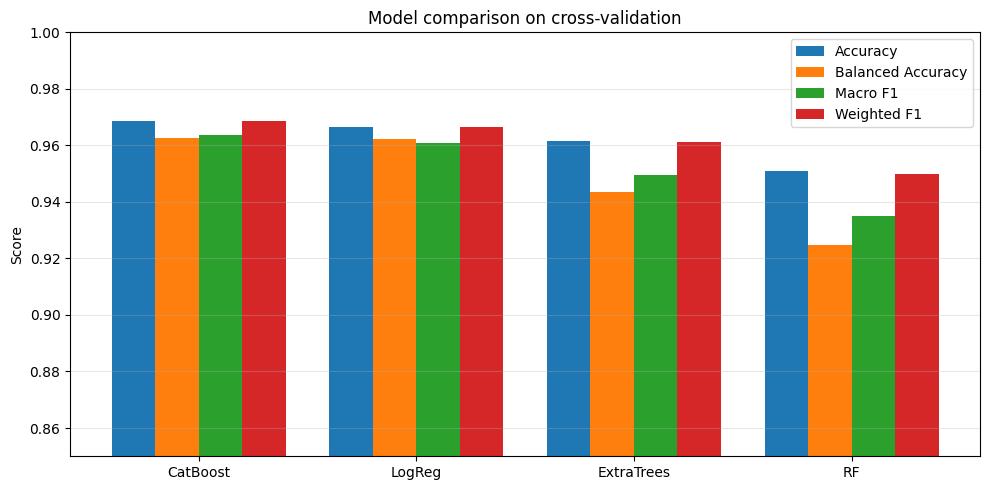

In [35]:


# bar chart compare model performance


plot_df = results_df.copy()

metrics_to_plot = ["acc_mean", "bal_acc_mean", "macro_f1_mean", "weighted_f1_mean"]
metric_labels = ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"]

x = np.arange(len(plot_df))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

for i, (col, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax.bar(x + i * width, plot_df[col], width=width, label=label)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(plot_df["model"], rotation=0)
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.00)
ax.set_title("Model comparison on cross-validation")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("model_comparison_scores", fig)
plt.show()

Saved figure: figures/model_cv_mean_std.png


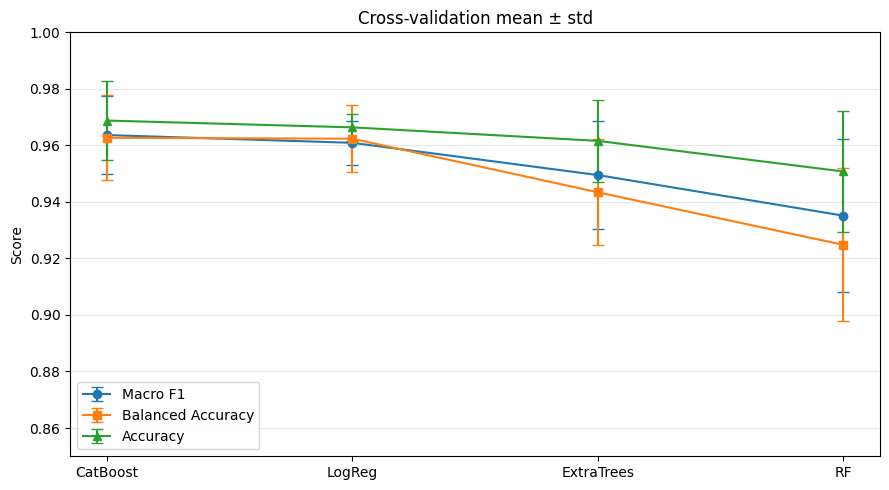

In [36]:


# Error-bar plot: mean ± std for main metrics

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(results_df))

ax.errorbar(
    x, results_df["macro_f1_mean"],
    yerr=results_df["macro_f1_std"],
    fmt="o-", capsize=4, label="Macro F1"
)

ax.errorbar(
    x, results_df["bal_acc_mean"],
    yerr=results_df["bal_acc_std"],
    fmt="s-", capsize=4, label="Balanced Accuracy"
)

ax.errorbar(
    x, results_df["acc_mean"],
    yerr=results_df["acc_std"],
    fmt="^-", capsize=4, label="Accuracy"
)

ax.set_xticks(x)
ax.set_xticklabels(results_df["model"])
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.00)
ax.set_title("Cross-validation mean ± std")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("model_cv_mean_std", fig)
plt.show()

Saved figure: figures/best_model_confusion_matrix.png


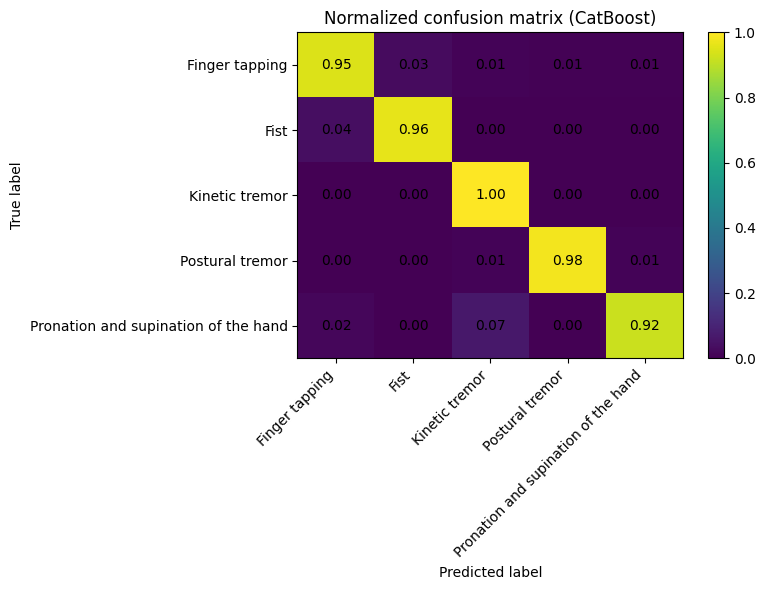

In [37]:


# Confusion matrix heatmap for the best model

labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, aspect="auto")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Normalized confusion matrix ({best_name})")

fig.colorbar(im, ax=ax)
plt.tight_layout()
save_fig("best_model_confusion_matrix", fig)
plt.show()



,precision,recall,f1-score
Finger tapping,0.958763,0.948980,0.953846
Fist,0.969697,0.964824,0.967254
Kinetic tremor,0.952941,1.000000,0.975904
Postural tremor,0.995283,0.981395,0.988290
Pronation and supination of the hand,0.949153,0.918033,0.933333


Saved figure: figures/best_model_per_class_metrics.png


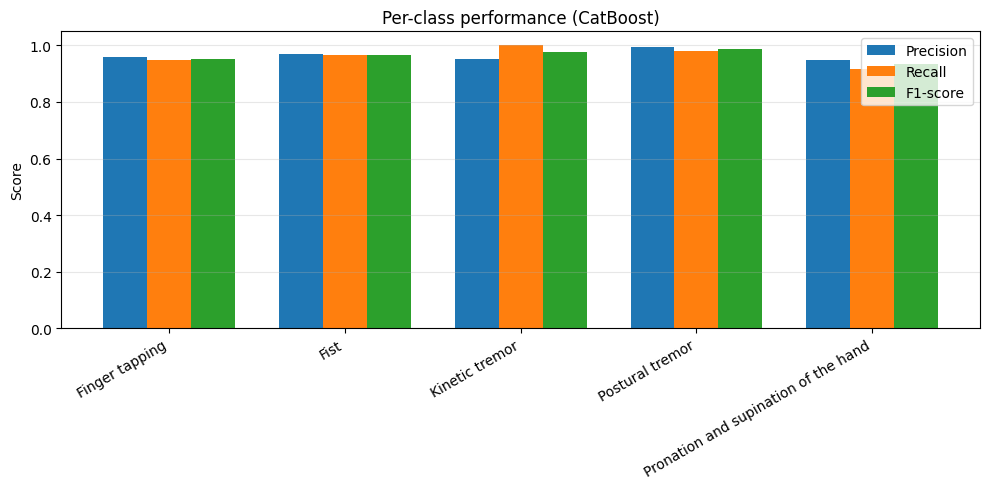

In [38]:

#Per-class precision / recall / F1 plot

report = classification_report(y, y_pred, output_dict=True)
class_names = sorted(y.unique())

class_df = pd.DataFrame({
    "precision": [report[c]["precision"] for c in class_names],
    "recall":    [report[c]["recall"] for c in class_names],
    "f1-score":  [report[c]["f1-score"] for c in class_names],
}, index=class_names)

display(class_df)

x = np.arange(len(class_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, class_df["precision"], width=width, label="Precision")
ax.bar(x,         class_df["recall"],    width=width, label="Recall")
ax.bar(x + width, class_df["f1-score"],  width=width, label="F1-score")

ax.set_xticks(x)
ax.set_xticklabels(class_df.index, rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.05)
ax.set_title(f"Per-class performance ({best_name})")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("best_model_per_class_metrics", fig)
plt.show()